# Differential regression (Appx 3): воспроизведение и проверка


updates:
* финансовые классы и модели вынесены в пакет `dml`
* исправлена замена удалённого в sklearn 1.2 параметра `normalize=True`
* вместо одного случайного сида и графиков — метрики (RMSE цены и дельт) по многим сидам
* добавлены эксперименты: чувствительность к λ, кривая обучения, рост размерности

Модели во всех экспериментах — полиномы степени 5

In [ ]:
# LIGHT = True: меньше сидов, меньше тестовая выборка, без n = 7 и m = 8000.
# N_THREADS: сколько ядер может занять линейная алгебра (numpy/sklearn).
#   Меньше ядер — машина меньше греется, но считает дольше.
LIGHT = False
N_THREADS = 2

import os
for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[var] = str(N_THREADS)

import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dml.simulators import BlackScholesCall, BachelierBasket, grid, uniform
from dml.models.regression import (make_polynomial, PolynomialRidge, PolynomialRidgeCV,
                                   DifferentialRegression)
from dml.metrics import evaluate_regressors
from dml.plotting import plot_methods

RESULTS = Path("../results/02_differential_regression")
RESULTS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 4)

DEGREE = 5
SEEDS = list(range(10 if LIGHT else 30))        # сравнение методов (разделы 2–3)
SEEDS_SWEEP = SEEDS[:10] if LIGHT else SEEDS[:20]  # перебор α и кривая обучения (разделы 4–5)
SEEDS_DIM = SEEDS[:5] if LIGHT else SEEDS[:10]     # размерность (раздел 6)
N_TEST = 2000 if LIGHT else 5000                # размер тестовой выборки
SIZES = [250, 500, 1000, 2000, 4000] + ([] if LIGHT else [8000])
DIMS = [1, 2, 3, 5] + ([] if LIGHT else [7])

## Постановка (как у авторов)

* **Black–Scholes, 1 актив:** колл K = 110, σ = 20 %, T = 2. Обучение: m = 200 точек на сетке S₀ ∈ [10, 200], по одному пути из каждой. Тест: `N_TEST` точек на той же сетке (5000, в облегчённом режиме 2000), точные цена и дельта.
* **Корзина Bachelier, n = 3:** колл на корзину K = 110, T = 3, волатильность корзины 20 (абсолютная), случайные веса, корреляции и волатильности. Обучение: m = 1000 точек S₀ ~ U[10, 200]ⁿ. Тест: `N_TEST` независимых точек.

Функции ниже создают данные и считают RMSE всех методов для одного сида.

In [2]:
def bs_data(seed, m=200):
    rng = np.random.default_rng(seed)
    opt = BlackScholesCall(K=110, vol=0.2, T=2)
    x = grid(10, 200, m)
    y, z = opt.sample_payoffs(x, rng)
    xt = grid(10, 200, N_TEST)
    return opt, x, y, z, xt


def bach_data(seed, n=3, m=1000):
    rng = np.random.default_rng(seed)
    opt = BachelierBasket.random(n, rng, basket_vol=20, K=110, T=3)
    x = uniform(10, 200, m, n, rng)
    y, z = opt.sample_payoffs(x, rng)
    xt = uniform(10, 200, N_TEST, n, rng)
    return opt, x, y, z, xt


def run(data_fn, methods, seed, **kw):
    opt, x, y, z, xt = data_fn(seed, **kw)
    return evaluate_regressors(methods, x, y, z, xt, opt.price(xt), opt.delta(xt))


def summarize(results, methods):
    rows = {}
    for name in methods:
        v = np.array([r[name] for r in results])
        rows[name] = {"RMSE цены (среднее)": v[:, 0].mean(), "± std": v[:, 0].std(),
                      "RMSE дельты (среднее)": v[:, 1].mean(), "± std ": v[:, 1].std()}
    return pd.DataFrame(rows).T


METHODS = {
    "OLS": lambda: make_polynomial(DEGREE),
    "RidgeCV": lambda: PolynomialRidgeCV(DEGREE),
    "Differential": lambda: DifferentialRegression(DEGREE),
}

## 1. Воспроизведение: один сид, как в оригинале

Те же графики, что у авторов: обучающие выплаты (кружки), предсказание и точная цена.

RidgeCV: выбранное alpha = 0.2420


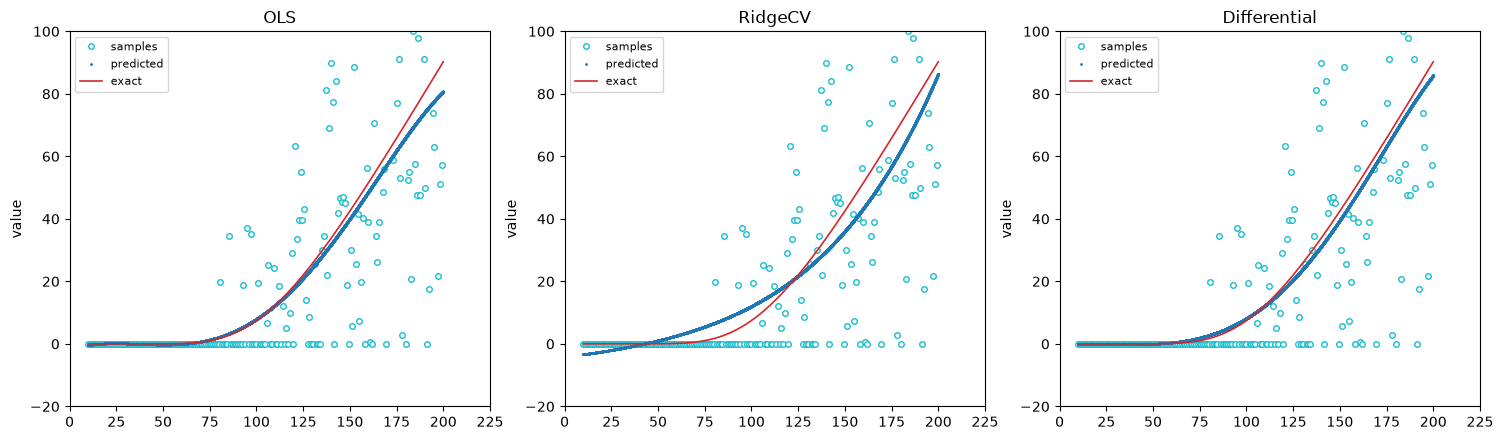

In [3]:
def fit_all(x, y, z, xt):
    preds = {}
    for name, make in METHODS.items():
        m = make()
        m.fit(x, y, z) if name == "Differential" else m.fit(x, y)
        preds[name] = m.predict(xt)
        if name == "RidgeCV":
            print(f"RidgeCV: выбранное alpha = {m.alpha_:.4f}")
    return preds

opt, x, y, z, xt = bs_data(seed=0)
fig = plot_methods(xt, opt.price(xt), fit_all(x, y, z, xt), samples=(x, y),
                   xlim=(0, 225), ylim=(-20, 100), save_path=RESULTS / "bs_single_seed.png")

RidgeCV: выбранное alpha = 0.3352


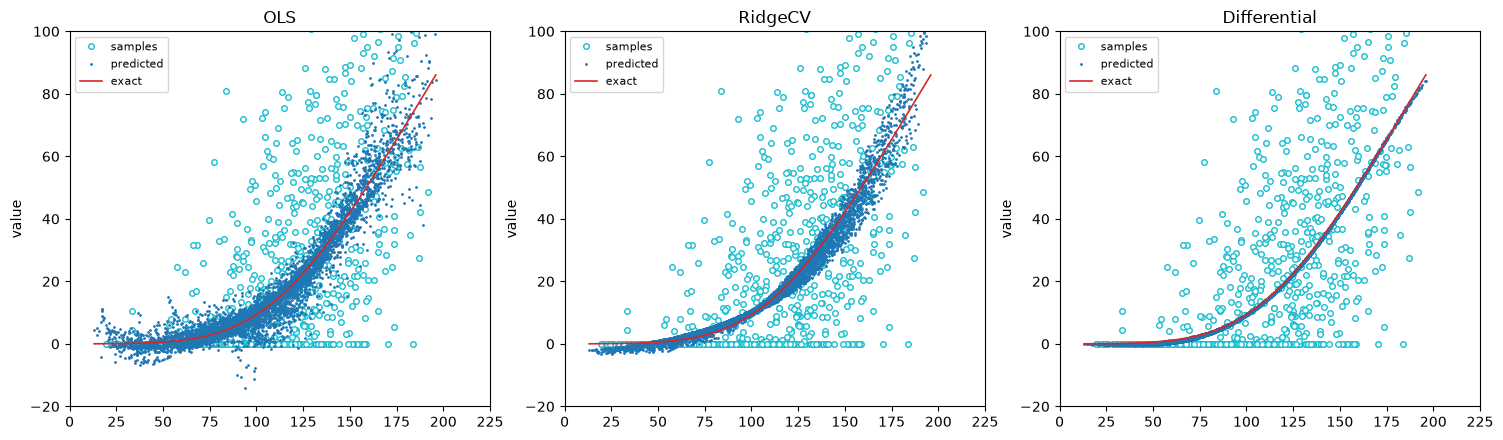

In [4]:
opt, x, y, z, xt = bach_data(seed=0)
fig = plot_methods(opt.basket(xt), opt.price(xt), fit_all(x, y, z, xt), samples=(opt.basket(x), y),
                   xlim=(0, 225), ylim=(-20, 100), save_path=RESULTS / "bachelier3_single_seed.png")

Картина совпадает с авторской: на корзине дифференциальная регрессия заметно ближе к точной цене, а в одномерном случае по одному графику разница видна плохо. Поэтому дальше - метрики по многим сидам

## 2. Сравнение методов по 30 сидам

Помимо трёх основных методов показаны два «технических» варианта:

* `OLS raw` и `RidgeCV raw` — полиномы на нестандартизованных входах (как в нашей первой версии ноутбука);
* `Differential std` — дифференциальная регрессия со стандартизацией входов (лучше обусловленная система).

Дельты базовых моделей считаются конечными разностями по обученному полиному, дифференциальная регрессия выдаёт их сама.

In [6]:
METHODS_EXT = {
    **METHODS,
    "OLS raw": lambda: make_polynomial(DEGREE, scale=False),
    "RidgeCV raw": lambda: PolynomialRidgeCV(DEGREE, scale=False),
    "Differential std": lambda: DifferentialRegression(DEGREE, standardize=True),
}
table_bs = summarize([run(bs_data, METHODS_EXT, s) for s in SEEDS], METHODS_EXT)
table_bs.to_csv(RESULTS / "table_black_scholes.csv")
table_bs

,RMSE цены (среднее),± std,RMSE дельты (среднее),± std
OLS,4.7106,2.1680,0.3622,0.2208
RidgeCV,4.5090,1.7144,0.2373,0.1183
Differential,2.6075,1.5003,0.0641,0.0152
OLS raw,4.1140,1.9297,0.1821,0.0983
RidgeCV raw,4.5371,2.1602,0.2993,0.1871
Differential std,2.5702,1.5533,0.0586,0.0183


In [7]:
table_bach = summarize([run(bach_data, METHODS_EXT, s) for s in SEEDS], METHODS_EXT)
table_bach.to_csv(RESULTS / "table_bachelier3.csv")
table_bach

,RMSE цены (среднее),± std,RMSE дельты (среднее),± std
OLS,5.3412,0.7192,0.2164,0.0344
RidgeCV,2.7046,0.5526,0.0571,0.0128
Differential,0.9624,0.4352,0.0135,0.0030
OLS raw,4.5149,0.6133,0.1512,0.0247
RidgeCV raw,8.0556,14.0743,0.3272,0.6410
Differential std,0.9339,0.4083,0.0146,0.0030


**Про `OLS raw`.** Он выглядит лучше «честного» OLS, но это не настоящее решение МНК: на сырых мономах степени 5 матрица почти вырождена, и решатель отбрасывает малые сингулярные числа, что работает как скрытая регуляризация. Со стандартизацией получается точное решение МНК (его же давал старый sklearn с `normalize=True`). Сравнивать методы корректно по стандартизованным вариантам.

## 3. Чувствительность к силе регуляризации α

Утверждение авторов: дифференциальная регрессия почти не зависит от α, а ridge требует подбора. Проверяем на корзине n = 3 (20 сидов). Для ridge α на шкале оригинального `normalize=True`, для дифференциальной регрессии α — множитель при ошибке в производных (α = 0 — обычный МНК).

price                delta        
метод     Differential   Ridge Differential   Ridge
alpha                                              
0.0001             NaN  4.2219          NaN  0.1276
0.0010          4.1043  3.7267       0.1340  0.0991
0.0100          2.7441  3.1874       0.0722  0.0727
0.1000          1.3901  2.8429       0.0236  0.0582
1.0000          1.0091  2.7803       0.0142  0.0530
10.0000         1.1294  6.1336       0.0141  0.0675
100.0000        1.2136     NaN       0.0142     NaN
1000.0000       1.2248     NaN       0.0143     NaN

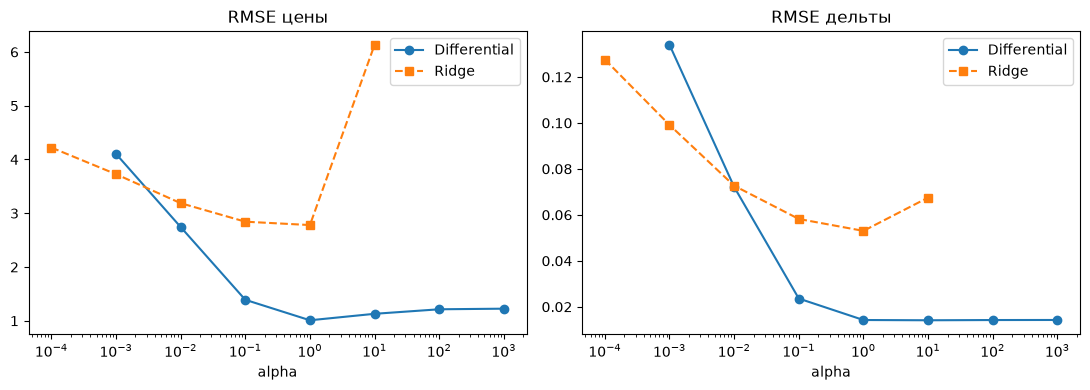

In [8]:
alphas_diff = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
alphas_ridge = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
sweep = {**{("Differential", a): (lambda a=a: DifferentialRegression(DEGREE, alpha=a)) for a in alphas_diff},
         **{("Ridge", a): (lambda a=a: PolynomialRidge(DEGREE, alpha=a)) for a in alphas_ridge}}
res = [run(bach_data, sweep, s) for s in SEEDS_SWEEP]
lam = pd.DataFrame({k: np.mean([r[k] for r in res], axis=0) for k in sweep}, index=["price", "delta"]).T
lam.index.names = ["метод", "alpha"]
lam.to_csv(RESULTS / "lambda_sensitivity.csv")

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axs, ["price", "delta"], ["RMSE цены", "RMSE дельты"]):
    for meth, mk in [("Differential", "o-"), ("Ridge", "s--")]:
        d = lam.loc[meth]
        ax.plot(d.index, d[col], mk, label=meth)
    ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_title(title); ax.legend()
fig.tight_layout(); fig.savefig(RESULTS / "lambda_sensitivity.png", dpi=120)
lam.unstack(0).round(4)

## 4. Кривая обучения: сколько данных нужно

Та же корзина n = 3, размер обучающей выборки от 250 до 8000 (20 сидов на точку).

OLS         RidgeCV         Differential        
        price   delta   price   delta        price   delta
m                                                         
250   13.5487  0.5705  4.1225  0.0747       1.9189  0.0269
500    8.1843  0.3472  3.2060  0.0584       1.2040  0.0188
1000   5.5186  0.2238  2.8256  0.0603       1.0091  0.0142
2000   3.5485  0.1420  2.1701  0.0506       0.6160  0.0100
4000   2.4133  0.0991  1.5874  0.0376       0.4815  0.0075
8000   1.7533  0.0737  1.1710  0.0319       0.3454  0.0063

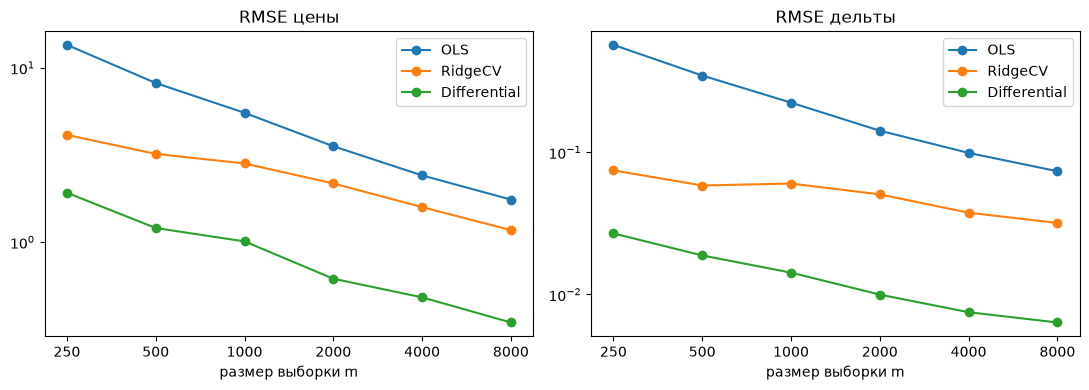

In [9]:
sizes = SIZES
curve = {}
for m in sizes:
    res = [run(bach_data, METHODS, s, m=m) for s in SEEDS_SWEEP]
    curve[m] = {k: np.mean([r[k] for r in res], axis=0) for k in METHODS}
curve_df = pd.DataFrame({(k, c): [curve[m][k][i] for m in sizes] for k in METHODS
                         for i, c in enumerate(["price", "delta"])}, index=sizes)
curve_df.index.name = "m"
curve_df.to_csv(RESULTS / "learning_curve.csv")

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axs, ["price", "delta"], ["RMSE цены", "RMSE дельты"]):
    for k in METHODS:
        ax.plot(sizes, curve_df[(k, col)], "o-", label=k)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("размер выборки m"); ax.set_title(title); ax.legend()
    ax.set_xticks(sizes, [str(m) for m in sizes]); ax.minorticks_off()
fig.tight_layout(); fig.savefig(RESULTS / "learning_curve.png", dpi=120)
curve_df.round(4)

## 5. Рост размерности

Число мономов степени ≤ 5 от n входов равно C(n+5, 5): 6, 21, 56, 252 и 792 для n = 1, 2, 3, 5, 7, а выборка остаётся m = 1000. Дифференциальная регрессия получает m·(n+1) уравнений вместо m, поэтому её выигрыш должен расти с n (10 сидов на точку; n = 7 считается дольше остальных и в облегчённом режиме пропускается).

In [10]:
from math import comb
dims = DIMS
dim_res = {}
for n in dims:
    res = [run(bach_data, METHODS, s, n=n) for s in SEEDS_DIM]
    dim_res[n] = {k: np.mean([r[k] for r in res], axis=0) for k in METHODS}
dim_df = pd.DataFrame({(k, c): [dim_res[n][k][i] for n in dims] for k in METHODS
                       for i, c in enumerate(["price", "delta"])}, index=dims)
dim_df.insert(0, ("число мономов", ""), [comb(n + DEGREE, DEGREE) for n in dims])
dim_df.index.name = "n"
dim_df.to_csv(RESULTS / "dimension.csv")
dim_df.round(4)

число мономов      OLS         RidgeCV         Differential        
                   price   delta   price   delta        price   delta
n                                                                    
1             6   1.9129  0.1506  1.9521  0.1249       1.1716  0.0267
2            21   3.0400  0.1624  2.3281  0.0820       0.7011  0.0128
3            56   5.4822  0.2265  2.7783  0.0574       1.0870  0.0149
5           252  13.8925  0.4023  2.6281  0.0328       0.9553  0.0127
7           792  68.6554  1.4914  2.9547  0.0287       1.3297  0.0146

RidgeCV: выбранное alpha = 12.0450


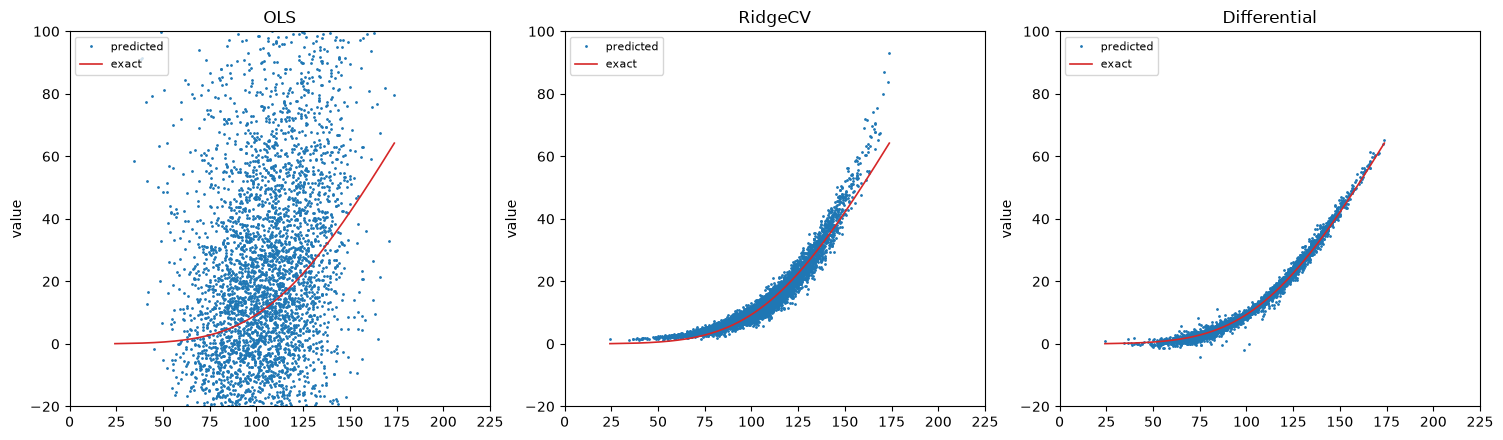

In [11]:
n_plot = max(DIMS)
opt, x, y, z, xt = bach_data(seed=0, n=n_plot)
fig = plot_methods(opt.basket(xt), opt.price(xt), fit_all(x, y, z, xt),
                   xlim=(0, 225), ylim=(-20, 100), save_path=RESULTS / f"bachelier{n_plot}_single_seed.png")

## 6. Выводы

Цифры ниже — средние по сидам из таблиц выше для полного режима (`LIGHT = False`); сиды фиксированы, поэтому при перезапуске они повторяются. В облегчённом режиме числа немного другие, выводы те же.

**Что воспроизвелось из утверждений авторов**

1. **Дифференциальная регрессия точнее обычной и ridge** (раздел 3). Black–Scholes: RMSE цены 2.61 против 4.51 у RidgeCV (в 1.7 раза), дельты 0.064 против 0.237 (в 3.7 раза). Корзина n = 3: 0.96 против 2.70 (в 2.8 раза) и 0.0135 против 0.057 (в 4.2 раза).
2. **Почти нет зависимости от α** (раздел 4). При α от 1 до 1000 RMSE цены 1.01–1.23, дельты 0.0142–0.0143. Ridge при лучшем α = 1 даёт 2.78, а при α = 10 уже 6.13. Выигрыш пропадает только при α ≤ 0.01, когда вклад производных становится пренебрежимым и метод вырождается в OLS.
3. **Не нужна кросс-валидация**: везде использовалось α = 1 без подбора, и это лучше ridge с подобранным α.


**Технические выводы для порта**

4. Полиномы на сырых входах [10, 200] плохо обусловлены (число обусловленности системы дифференциальной регрессии ~1e22). Результат держится на усечении в `pinv`, а «OLS raw» выглядит лучше настоящего OLS только из-за скрытой регуляризации. Со стандартизацией входов (`standardize=True`) дифференциальная регрессия даёт ту же точность, но система хорошо обусловлена — этот вариант надёжнее.